In [1]:
# Данный ноутбук принимает на вход таблицу формата csv, содержащую следующие колонки:
# Год: int
# Муниципалитет: str
# Пол: str
# Возрастная группа: str
# Причина смерти: str
# Стандартный вес группы: str, должен быть указан в процентах (например '4,4')
# Число умерших: int
# Численность населения: int, имеется в виду численность населения возрастной группы

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import math
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_colwidth', None)

In [3]:
# Загрузка исходной таблицы.
df = pd.read_csv("Тестовое _ Данные - Лист1.csv")

In [4]:
# Определение уровня значимости, который будет использоваться для расчётов.
alpha = 0.05
# Расчёт уровня доверия.
CL = int((1-alpha)*100)

# Содержание таблицы

In [5]:
df.head(50)

,Год,Муниципалитет,Пол,Возрастная группа,Причина смерти,Стандартный вес группы,Число умерших,Численность населения
0,2017,Район 1,Женщины,1-4,Болезни сердца,4,0,155
1,2017,Район 1,Женщины,1-4,Другие болезни органов дыхания,4,0,155
2,2017,Район 1,Женщины,1-4,Другие болезни системы кровообращения,4,0,155
3,2017,Район 1,Женщины,1-4,Острые респираторные заболевания,4,0,155
4,2017,Район 1,Женщины,10-14,Болезни сердца,"5,5",0,163
5,2017,Район 1,Женщины,10-14,Другие болезни органов дыхания,"5,5",0,163
6,2017,Район 1,Женщины,10-14,Другие болезни системы кровообращения,"5,5",0,163
7,2017,Район 1,Женщины,10-14,Острые респираторные заболевания,"5,5",0,163
8,2017,Район 1,Женщины,15-19,Болезни сердца,"5,5",0,132
9,2017,Район 1,Женщины,15-19,Другие болезни органов дыхания,"5,5",0,132


In [6]:
# Диапазоны значений колонок
print('Диапазоны значений колонок:', '\n')

for column in df.columns:
    print(column, df[column].unique().tolist(), '\n')

Диапазоны значений колонок: 

Год [2017, 2018, 2019, 2020, 2021, 2022, 2023] 

Муниципалитет ['Район 1', 'Район 2', 'Район 3'] 

Пол ['Женщины', 'Мужчины'] 

Возрастная группа ['1-4', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '5-9', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-84', '85+', 'до 1'] 

Причина смерти ['Болезни сердца', 'Другие болезни органов дыхания', 'Другие болезни системы кровообращения', 'Острые респираторные заболевания'] 

Стандартный вес группы ['4', '5,5', '6', '6,5', '7', '5', '2,5', '1'] 

Число умерших [0, 1, 2, 3, 4, 8, 10, 5, 11, 13, 6, 12, 7, 9] 

Численность населения [155, 163, 132, 135, 122, 131, 144, 133, 152, 342, 143, 159, 105, 54, 35, 11, 2, 21, 116, 129, 94, 100, 147, 149, 354, 174, 164, 141, 83, 71, 28, 16, 17, 112, 72, 96, 118, 74, 84, 202, 89, 82, 24, 7, 1, 22, 98, 113, 91, 49, 125, 86, 242, 95, 103, 88, 59, 44, 15, 10, 27, 781, 835, 661, 654, 994, 1223, 1172, 899, 718, 958, 849, 933, 732, 493, 217, 334, 

# Приведение входных данных к удобному виду

In [7]:
# Приведение колонки 'Стандартный вес группы' исходной таблицы к виду 0.01 (т.е. доли, а не проценты).
df['Стандартный вес группы'] = df['Стандартный вес группы'].str.replace(',', '.').astype(float) / 100

# Сопоставление динамики в муниципалитетах

## Общая смертность

In [8]:
# Схлопывание информации в таблице df по причинам смерти.
df_group = df.groupby(["Год", "Пол", "Муниципалитет", "Возрастная группа", "Стандартный вес группы", "Численность населения"], as_index=False).sum()
df_group.drop(['Причина смерти'], axis=1, inplace=True)
# Расчёт СКС.
df_group['СКС'] = 100000 * df_group['Число умерших'] * df_group['Стандартный вес группы'] / df_group['Численность населения']
# Схлопывание информации в таблице df_group по возрастным группам.
df_group = df_group.groupby(["Год", "Пол", "Муниципалитет"], as_index=False).sum()
df_group.drop(['Возрастная группа'], axis=1, inplace=True)
# Расчёт доли умерших.
df_group['Доля умерших'] = df_group['Число умерших'] / df_group['Численность населения']
# Создание колонки 'Муниципалитет/Пол'.
df_group['Муниципалитет/Пол'] = df_group[['Муниципалитет', 'Пол']].apply(lambda x: '/'.join(x), axis=1)
# Преобразование значений колонки 'Доля умерших' для дальнейшей отрисовки.
df_group['Доля умерших'] = (df_group[['Доля умерших', 'Пол']]
    .apply(lambda x: x['Доля умерших'] if x['Пол']=='Женщины' else -x['Доля умерших'], axis=1))
# Преобразование значений колонки 'СКС' для дальнейшей отрисовки.
df_group['СКС'] = (df_group[['СКС', 'Пол']]
    .apply(lambda x: x['СКС'] if x['Пол']=='Женщины' else -x['СКС'], axis=1))

In [9]:
df_group

,Год,Пол,Муниципалитет,Стандартный вес группы,Численность населения,Число умерших,СКС,Доля умерших,Муниципалитет/Пол
0,2017,Женщины,Район 1,1.0,2174,6,2899.875212,0.002760,Район 1/Женщины
1,2017,Женщины,Район 2,1.0,1403,7,882.136006,0.004989,Район 2/Женщины
2,2017,Женщины,Район 3,1.0,12985,37,575.416559,0.002849,Район 3/Женщины
3,2017,Мужчины,Район 1,1.0,2271,13,-709.141607,-0.005724,Район 1/Мужчины
4,2017,Мужчины,Район 2,1.0,1559,8,-767.700646,-0.005131,Район 2/Мужчины
5,2017,Мужчины,Район 3,1.0,11669,30,-654.268312,-0.002571,Район 3/Мужчины
6,2018,Женщины,Район 1,1.0,2171,6,789.500990,0.002764,Район 1/Женщины
7,2018,Женщины,Район 2,1.0,1420,4,504.276212,0.002817,Район 2/Женщины
8,2018,Женщины,Район 3,1.0,13048,37,550.267523,0.002836,Район 3/Женщины
9,2018,Мужчины,Район 1,1.0,2238,8,-505.806043,-0.003575,Район 1/Мужчины


Text(0.5, 1.0, 'Суммарная доля умерших')

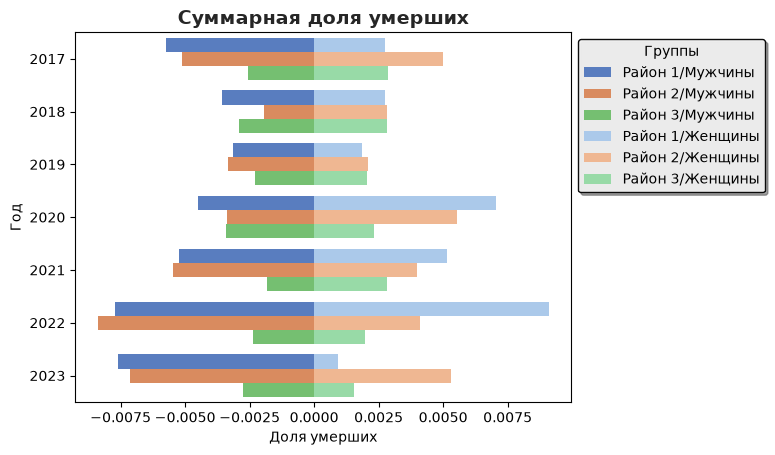

In [10]:
f, ax = plt.subplots()
# Отрисовка данных по мужчинам.
sns.barplot(df_group[df_group['Пол']=='Мужчины'], x='Доля умерших', y='Год', hue='Муниципалитет/Пол',
            errorbar=None, orient='h', ax=ax, palette='muted')
# Отрисовка данных по женщинам.
sns.barplot(df_group[df_group['Пол']=='Женщины'], x='Доля умерших', y='Год', hue='Муниципалитет/Пол',
            errorbar=None, orient='h', ax=ax, palette='pastel')
# Отрисовка легенды
legend = plt.legend(loc='upper left',
           bbox_to_anchor=(1, 1),
           title='Группы',
           facecolor='#f0f0f0',        # Светло-серый фон
           edgecolor='black',          # Цвет рамки
           framealpha=0.95,            # Непрозрачность
           shadow=True,                # Тень
           fancybox=True               # Скругление углов
          )
# Отрисовка подписи
ax.set_title('Суммарная доля умерших', fontsize=14, fontweight='bold', alpha=0.85)

Text(0.5, 1.0, 'СКС')

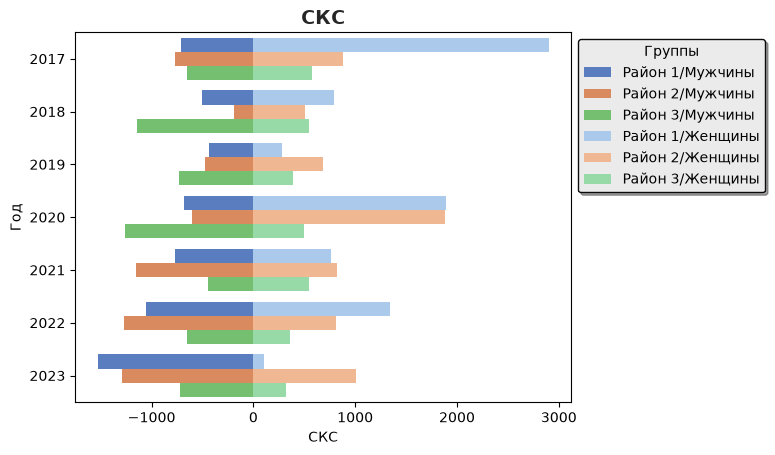

In [11]:
f, ax = plt.subplots()
sns.barplot(df_group[df_group['Пол']=='Мужчины'], x='СКС', y='Год', hue='Муниципалитет/Пол',
            errorbar=None, orient='h', ax=ax, palette='muted')
sns.barplot(df_group[df_group['Пол']=='Женщины'], x='СКС', y='Год', hue='Муниципалитет/Пол',
            errorbar=None, orient='h', ax=ax, palette='pastel')
# Отрисовка легенды
legend = plt.legend(loc='upper left',
           bbox_to_anchor=(1, 1),
           title='Группы',
           facecolor='#f0f0f0',        # Светло-серый фон
           edgecolor='black',          # Цвет рамки
           framealpha=0.95,            # Непрозрачность
           shadow=True,                # Тень
           fancybox=True               # Скругление углов
          )
# Отрисовка подписи
ax.set_title('СКС', fontsize=14, fontweight='bold', alpha=0.85)

In [12]:
# Вывод: похоже, что есть корреляция смертности по годам между районами 1 и 2.

# Пермутационный тест

In [13]:
# Идея: проверить наличие корреляции между муниципалитетами по годам.

## Функции

In [14]:
def pearson_spearman(df: pd.DataFrame,
                     district_1: str,
                     district_2: str,
                     gender: str,
                     target: str
                    ):

    '''
    Вычисляет коэффициенты корреляции Пирсона и Спирмана для двух муниципалитетов по полу.
    df: таблица формата df_group
    district_1: муниципалитет 1
    district_2: муниципалитет 2
    gender: пол
    target: 'Доля умерших' или 'СКС'
    Выводит входные параметры и коэффициенты корреляций Пирсона и Спирмана.
    '''
    
    # print(district_1, district_2, gender, target, '\n')
    # Создание срезов
    df_slice_1 = df[(df['Муниципалитет']==district_1)&(df['Пол']==gender)]
    df_slice_2 = df[(df['Муниципалитет']==district_2)&(df['Пол']==gender)]
    # Преобразование колонок СКС или Доля умерших в вектора.
    X_1 = df_slice_1[target].to_numpy()
    X_2 = df_slice_2[target].to_numpy()
    # Вычисление средних.
    X_1_mean = X_1.mean()
    X_2_mean = X_2.mean()
    # Создание векторов рангов для корреляции Спирмана.
    X_1_rank = stats.rankdata(X_1, method='average')
    X_2_rank = stats.rankdata(X_2, method='average')
    # Вычисление средних для векторов рангов.
    X_1_rank_mean = X_1_rank.mean()
    X_2_rank_mean = X_2_rank.mean()
    # Вычисление коэффициента корреляции Пирсона.
    r_pearson = ((X_1-X_1_mean)*(X_2-X_2_mean)).sum()/np.sqrt((np.square(X_1-X_1_mean).sum()*np.square(X_2-X_2_mean).sum()))
    # Вычисление коэффициента корреляции Спирмана.
    r_spearman = ((X_1_rank-X_1_rank_mean)*(X_2_rank-X_2_rank_mean)).sum()/np.sqrt((np.square(X_1_rank-X_1_rank_mean).sum()*np.square(X_2_rank-X_2_rank_mean).sum()))
    return district_1, district_2, gender, target, r_pearson, r_spearman

In [15]:
def permutation(df: pd.DataFrame,
                district_1: str,
                district_2: str,
                gender: str,
                target: str
               ):

    '''
    Вычисляет коэффициенты корреляции Пирсона и Спирмана для двух муниципалитетов по полу и
    проверяет статистическую значимость полученных значений с помощью пермутационного теста.
    df: таблица формата df_group
    district_1: муниципалитет 1
    district_2: муниципалитет 2
    gender: пол
    target: 'Доля умерших' или 'СКС'
    Возвращает входные параметры, коэффициенты корреляций Пирсона и Спирмана, и уровень сначимости этих коэффициентов.
    '''

    # print(district_1, district_2, gender, target, '\n')
    # Создание срезов
    df_slice_1 = df[(df['Муниципалитет']==district_1)&(df['Пол']==gender)]
    df_slice_2 = df[(df['Муниципалитет']==district_2)&(df['Пол']==gender)]
    # Преобразование колонок СКС или Доля умерших в вектора.
    X_1 = df_slice_1[target].to_numpy()
    X_2 = df_slice_2[target].to_numpy()
    # Вычисление средних.
    X_1_mean = X_1.mean()
    X_2_mean = X_2.mean()
    # Создание векторов рангов для корреляции Спирмана.
    X_1_rank = stats.rankdata(X_1, method='average')
    X_2_rank = stats.rankdata(X_2, method='average')
    # Вычисление средних для векторов рангов.
    X_1_rank_mean = X_1_rank.mean()
    X_2_rank_mean = X_2_rank.mean()
    # Вычисление коэффициента корреляции Пирсона.
    r_obs_pearson = ((X_1-X_1_mean)*(X_2-X_2_mean)).sum()/np.sqrt((np.square(X_1-X_1_mean).sum()*np.square(X_2-X_2_mean).sum()))
    # Вычисление коэффициента корреляции Спирмана.
    r_obs_spearman = ((X_1_rank-X_1_rank_mean)*(X_2_rank-X_2_rank_mean)).sum()/np.sqrt((np.square(X_1_rank-X_1_rank_mean).sum()*np.square(X_2_rank-X_2_rank_mean).sum()))

    # Число пермутаций.
    n_permutations = 20000
    # Создание списков для сохранения значений коэффициентов для пермутаций.
    r_null_pearson = []
    r_null_spearman = []

    for _ in range(n_permutations):
        # Перемешивание второго ряда.
        X_2_shuffled = np.random.permutation(X_2)
        X_2_rank_shuffled = np.random.permutation(X_2_rank)
        # Вычисление среднего перемешанного ряда.
        X_2_shuffled_mean = X_2_shuffled.mean()
        X_2_rank_shuffled_mean = X_2_rank_shuffled.mean()
        # Расчёт коэфициентов и добвление их в списки.
        r_null_pearson.append(((X_1-X_1_mean)*(X_2_shuffled-X_2_shuffled_mean)).sum()/np.sqrt((np.square(X_1-X_1_mean).sum()*np.square(X_2_shuffled-X_2_shuffled_mean).sum())))
        r_null_spearman.append(((X_1_rank-X_1_rank_mean)*(X_2_rank_shuffled-X_2_rank_shuffled_mean)).sum()/np.sqrt((np.square(X_1_rank-X_1_rank_mean).sum()*np.square(X_2_rank_shuffled-X_2_rank_shuffled_mean).sum())))

    # Преобразование списков в вектора.
    r_null_pearson = np.array(r_null_pearson)
    r_null_spearman = np.array(r_null_spearman)

    # Вычисление уровней значимости.
    p_value_pearson = np.mean(np.abs(r_null_pearson) >= np.abs(r_obs_pearson))
    p_value_spearman = np.mean(np.abs(r_null_spearman) >= np.abs(r_obs_spearman))

    # print(f"кореляция Пирсона: {r_obs_pearson:.4f}")
    # print(f"p-value (пермутационный) Пирсон: {p_value_pearson:.4f}")
    # print(f"кореляция Спирмена: {r_obs_spearman:.4f}")
    # print(f"p-value (пермутационный) Спирмен: {p_value_spearman:.4f}")
    return district_1, district_2, gender, target, r_obs_pearson, p_value_pearson, r_obs_spearman, p_value_spearman

In [16]:
def permutation_df(df):

    '''
    Вычисляет коэффициенты корреляции Пирсона и Спирмана для колонок 'СКС' и 'Доля умерших' таблицы формата df_group,
    и проверяет статистическую значимость полученных значений с помощью пермутационного теста.
    df: таблица формата df_group
    Возвращает таблицу содержащую колонки, 'Муниципалитет_1', 'Муниципалитет_2', 'Пол', 'Метрика' (СКС или Доля умерших),
                    'Корреляция Пирсона', 'P-value (пермутационный) Пирсон',
                    'Корреляция Спирмена', 'P-value (пермутационный) Спирмен'.
    '''

    columns_list = ['Муниципалитет_1', 'Муниципалитет_2', 'Пол', 'Метрика',
                    'Корреляция Пирсона', 'P-value (пермутационный) Пирсон',
                    'Корреляция Спирмена', 'P-value (пермутационный) Спирмен']

    districts = df['Муниципалитет'].unique().tolist()
    genders = df['Пол'].unique().tolist()
    targets = ['Доля умерших', 'СКС']
    df_output = pd.DataFrame()
    for target in targets:
        row_list = [permutation(df, district_1, district_2, gender, target)
                    for district_1 in districts for district_2 in districts for gender in genders
                    if district_1 < district_2]

        df_output = pd.concat([df_output, pd.DataFrame(row_list, columns=columns_list)], ignore_index=True)

    df_output.sort_values(['Муниципалитет_1', 'Муниципалитет_2', 'Пол', 'Метрика'], inplace=True, ignore_index=True)

    return df_output

## Вычисления

In [17]:
permutation_df(df_group)

,Муниципалитет_1,Муниципалитет_2,Пол,Метрика,Корреляция Пирсона,P-value (пермутационный) Пирсон,Корреляция Спирмена,P-value (пермутационный) Спирмен
0,Район 1,Район 2,Женщины,Доля умерших,0.226884,0.61905,0.142857,0.77795
1,Район 1,Район 2,Женщины,СКС,0.355962,0.41400,0.214286,0.66030
2,Район 1,Район 2,Мужчины,Доля умерших,0.945755,0.00265,0.928571,0.00670
3,Район 1,Район 2,Мужчины,СКС,0.822025,0.01305,0.964286,0.00290
4,Район 1,Район 3,Женщины,Доля умерших,0.043113,0.92930,0.107143,0.84370
5,Район 1,Район 3,Женщины,СКС,0.577658,0.17385,0.607143,0.16585
6,Район 1,Район 3,Мужчины,Доля умерших,-0.117496,0.79705,-0.071429,0.90585
7,Район 1,Район 3,Мужчины,СКС,-0.310635,0.51310,-0.607143,0.16515
8,Район 2,Район 3,Женщины,Доля умерших,-0.163412,0.71380,-0.178571,0.71165
9,Район 2,Район 3,Женщины,СКС,0.009241,0.99375,-0.178571,0.70980


### Все причины смерти кроме болезней сердца

In [18]:
# Схлопывание информации в таблице df по причинам смерти (все причины смерти кроме болезней сердца).
df_group_other = df[df['Причина смерти']!='Болезни сердца'].groupby(["Год", "Пол", "Муниципалитет", "Возрастная группа", "Стандартный вес группы", "Численность населения"], as_index=False).sum()
df_group_other.drop(['Причина смерти'], axis=1, inplace=True)
# Расчёт СКС.
df_group_other['СКС'] = 100000 * df_group_other['Число умерших'] * df_group_other['Стандартный вес группы'] / df_group_other['Численность населения']
# Схлопывание информации в таблице df_group_other по возрастным группам.
df_group_other = df_group_other.groupby(["Год", "Пол", "Муниципалитет"], as_index=False).sum()
df_group_other.drop(['Возрастная группа'], axis=1, inplace=True)
# Расчёт доли умерших.
df_group_other['Доля умерших'] = df_group_other['Число умерших'] / df_group_other['Численность населения']
# Создание колонки 'Муниципалитет/Пол'.
df_group_other['Муниципалитет/Пол'] = df_group_other[['Муниципалитет', 'Пол']].apply(lambda x: '/'.join(x), axis=1)
# Преобразование значений колонки 'Доля умерших' для дальнейшей отрисовки.
df_group_other['Доля умерших'] = (df_group_other[['Доля умерших', 'Пол']]
    .apply(lambda x: x['Доля умерших'] if x['Пол']=='Женщины' else -x['Доля умерших'], axis=1))
# Преобразование значений колонки 'СКС' для дальнейшей отрисовки.
df_group_other['СКС'] = (df_group_other[['СКС', 'Пол']]
    .apply(lambda x: x['СКС'] if x['Пол']=='Женщины' else -x['СКС'], axis=1))

In [19]:
permutation_df(df_group_other)

,Муниципалитет_1,Муниципалитет_2,Пол,Метрика,Корреляция Пирсона,P-value (пермутационный) Пирсон,Корреляция Спирмена,P-value (пермутационный) Спирмен
0,Район 1,Район 2,Женщины,Доля умерших,0.088672,0.84635,0.384615,0.38795
1,Район 1,Район 2,Женщины,СКС,0.427406,0.37745,0.307692,0.52265
2,Район 1,Район 2,Мужчины,Доля умерших,0.266045,0.55155,0.090094,0.85725
3,Район 1,Район 2,Мужчины,СКС,0.227184,0.59145,0.630656,0.13915
4,Район 1,Район 3,Женщины,Доля умерших,0.483780,0.27660,0.704187,0.10510
5,Район 1,Район 3,Женщины,СКС,0.439342,0.31550,0.592999,0.17895
6,Район 1,Район 3,Мужчины,Доля умерших,-0.511609,0.23805,-0.214286,0.66930
7,Район 1,Район 3,Мужчины,СКС,-0.611894,0.13755,-0.464286,0.30535
8,Район 2,Район 3,Женщины,Доля умерших,0.252111,0.59045,0.185312,0.71610
9,Район 2,Район 3,Женщины,СКС,0.292177,0.50405,0.111187,0.84605


### Болезни сердца

In [20]:
# Срез по таблице df по болезням сердца.
df_group_heart = df[df['Причина смерти']=='Болезни сердца']
df_group_heart.drop(['Причина смерти'], axis=1, inplace=True)
# Расчёт СКС.
df_group_heart['СКС'] = 100000 * df_group_heart['Число умерших'] * df_group_heart['Стандартный вес группы'] / df_group_heart['Численность населения']
# Схлопывание информации в таблице df_group_heart по возрастным группам.
df_group_heart = df_group_heart.groupby(["Год", "Пол", "Муниципалитет"], as_index=False).sum()
df_group_heart.drop(['Возрастная группа'], axis=1, inplace=True)
# Расчёт доли умерших.
df_group_heart['Доля умерших'] = df_group_heart['Число умерших'] / df_group_heart['Численность населения']
# Создание колонки 'Муниципалитет/Пол'.
df_group_heart['Муниципалитет/Пол'] = df_group_heart[['Муниципалитет', 'Пол']].apply(lambda x: '/'.join(x), axis=1)
# Преобразование значений колонки 'Доля умерших' для дальнейшей отрисовки.
df_group_heart['Доля умерших'] = (df_group_heart[['Доля умерших', 'Пол']]
    .apply(lambda x: x['Доля умерших'] if x['Пол']=='Женщины' else -x['Доля умерших'], axis=1))
# Преобразование значений колонки 'СКС' для дальнейшей отрисовки.
df_group_heart['СКС'] = (df_group_heart[['СКС', 'Пол']]
    .apply(lambda x: x['СКС'] if x['Пол']=='Женщины' else -x['СКС'], axis=1))

In [21]:
permutation_df(df_group_heart)

,Муниципалитет_1,Муниципалитет_2,Пол,Метрика,Корреляция Пирсона,P-value (пермутационный) Пирсон,Корреляция Спирмена,P-value (пермутационный) Спирмен
0,Район 1,Район 2,Женщины,Доля умерших,-0.062449,0.88895,-0.107143,0.84060
1,Район 1,Район 2,Женщины,СКС,0.155351,0.72395,0.214286,0.66620
2,Район 1,Район 2,Мужчины,Доля умерших,0.921016,0.00565,0.928571,0.00610
3,Район 1,Район 2,Мужчины,СКС,0.884850,0.00275,0.928571,0.00565
4,Район 1,Район 3,Женщины,Доля умерших,-0.202508,0.65695,0.142857,0.77885
5,Район 1,Район 3,Женщины,СКС,0.541686,0.19980,0.607143,0.16745
6,Район 1,Район 3,Мужчины,Доля умерших,-0.460682,0.28940,-0.285714,0.55175
7,Район 1,Район 3,Мужчины,СКС,-0.337771,0.48415,-0.535714,0.23760
8,Район 2,Район 3,Женщины,Доля умерших,-0.458102,0.30195,-0.392857,0.39760
9,Район 2,Район 3,Женщины,СКС,-0.495517,0.25690,-0.428571,0.35055


In [22]:
# Вывод: Есть корреляция смертности среди мужчин по годам между районами 1 и 2.